# Work in progress draft

# Quickstart: ECMWF AIFS ENS forecast - dynamical.org Icechunk Zarr

ECMWF's Artificial Intelligence Forecasting System (AIFS) ENS is the ensemble configuration of the AI based AIFS weather forecast model. It produces 51-member global ensemble forecasts at 0.25° resolution, every 6 hours, out to 15 days in 6 hourly steps.

This dataset provides AIFS ENS forecasts from July 2025 to present, transformed into a single analysis-ready dataset by [dynamical.org](https://dynamical.org).

Dataset documentation: https://dynamical.org/catalog/ecmwf-aifs-ens-forecast/

Dataset licenced [CC-BY-4.0](https://creativecommons.org/licenses/by/4.0/) and [ECMWF Terms of Use](https://apps.ecmwf.int/datasets/licences/general/).

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install dynamical-catalog

In [2]:
import dynamical_catalog

ds = dynamical_catalog.open("ecmwf-aifs-ens-forecast", chunks=None)
ds

<xarray.Dataset> Size: 279TB
Dimensions:                                     (init_time: 1271,
                                                 lead_time: 61,
                                                 ensemble_member: 51,
                                                 latitude: 721, longitude: 1440)
Coordinates:
  * init_time                                   (init_time) datetime64[ns] 10kB ...
    ingested_forecast_length                    (init_time) timedelta64[ns] 10kB ...
    expected_forecast_length                    (init_time) timedelta64[ns] 10kB ...
  * lead_time                                   (lead_time) timedelta64[ns] 488B ...
    valid_time                                  (init_time, lead_time) datetime64[ns] 620kB ...
  * ensemble_member                             (ensemble_member) int16 102B ...
  * latitude                                    (latitude) float64 6kB 90.0 ....
  * longitude                                   (longitude) float64 12kB -180...
    spatial_ref                                 int64 8B ...
Data variables: (12/17)
    dew_point_temperature_2m                    (init_time, lead_time, ensemble_member, latitude, longitude) float32 16TB ...
    downward_short_wave_radiation_flux_surface  (init_time, lead_time, ensemble_member, latitude, longitude) float32 16TB ...
    geopotential_height_500hpa                  (init_time, lead_time, ensemble_member, latitude, longitude) float32 16TB ...
    geopotential_height_850hpa                  (init_time, lead_time, ensemble_member, latitude, longitude) float32 16TB ...
    geopotential_height_925hpa                  (init_time, lead_time, ensemble_member, latitude, longitude) float32 16TB ...
    downward_long_wave_radiation_flux_surface   (init_time, lead_time, ensemble_member, latitude, longitude) float32 16TB ...
    ...                                          ...
    temperature_850hpa                          (init_time, lead_time, ensemble_member, latitude, longitude) float32 16TB ...
    wind_u_100m                                 (init_time, lead_time, ensemble_member, latitude, longitude) float32 16TB ...
    wind_v_100m                                 (init_time, lead_time, ensemble_member, latitude, longitude) float32 16TB ...
    total_cloud_cover_atmosphere                (init_time, lead_time, ensemble_member, latitude, longitude) float32 16TB ...
    wind_u_10m                                  (init_time, lead_time, ensemble_member, latitude, longitude) float32 16TB ...
    wind_v_10m                                  (init_time, lead_time, ensemble_member, latitude, longitude) float32 16TB ...
Attributes:
    dataset_id:           ecmwf-aifs-ens-forecast
    dataset_version:      0.1.0
    name:                 ECMWF AIFS ENS forecast
    description:          Ensemble weather forecasts from the ECMWF Artificia...
    attribution:          ECMWF AIFS ENS forecast data processed by dynamical...
    license:              CC-BY-4.0
    spatial_domain:       Global
    spatial_resolution:   0.25 degrees (~20km)
    time_domain:          Forecasts initialized 2025-07-02 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 6 hours
    forecast_domain:      Forecast lead time 0-360 hours (0-15 days) ahead
    forecast_resolution:  6 hourly

This is an ensemble forecast dataset with five dimensions: `init_time` (when the forecast run began), `lead_time` (how far ahead the forecast extends), `ensemble_member` (0 = control, 1–50 = perturbed), and `latitude` / `longitude`. The `valid_time` coordinate combines `init_time` and `lead_time` to give the actual forecasted time.

Each of the 51 members is one plausible future. Together they sample the range of outcomes the model considers possible for a given forecast. Let's start by visualizing all 51 members at a single point.

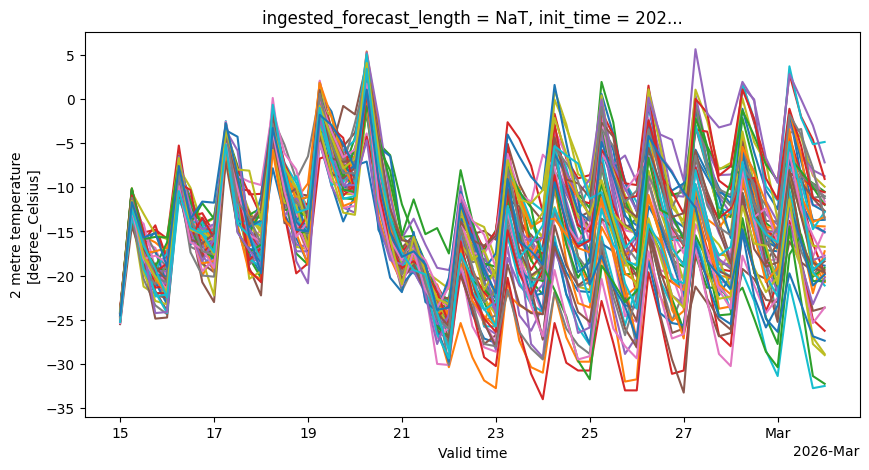

In [3]:
# 15-day 2 m temperature forecast for Ulaanbaatar, Mongolia, initialized in deep winter.
plot_ds = ds.sel(init_time="2026-02-15T00", latitude=47.92, longitude=106.92, method="nearest")
_ = plot_ds["temperature_2m"].plot( x="valid_time", hue="ensemble_member", add_legend=False, figsize=(10, 5))

### Quantile bands

With 51 members it's often easier to read the ensemble as a distribution. Quantiles across `ensemble_member` give a compact summary of the forecast uncertainty.

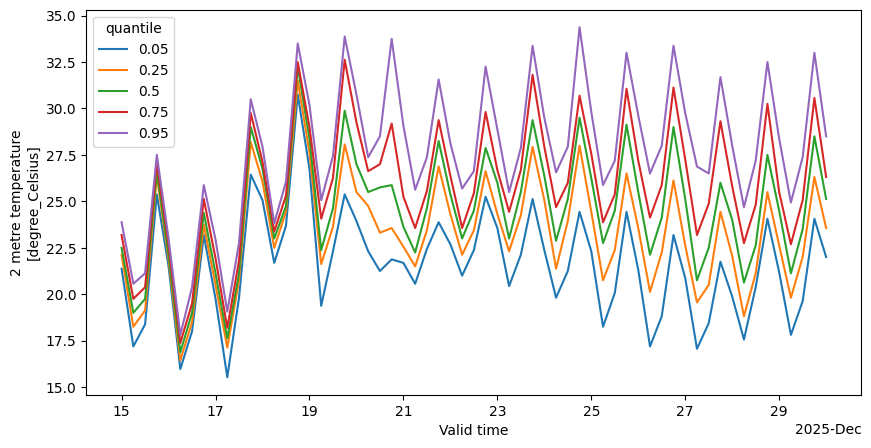

In [4]:
# Quantile summary of the ensemble distribution. Buenos Aires in mid-summer
plot_ds = ds.sel(init_time="2025-12-15T00", latitude=-34.61, longitude=-58.38, method="nearest")
(
    plot_ds["temperature_2m"]
    .quantile([0.05, 0.25, 0.5, 0.75, 0.95], dim="ensemble_member")
    .plot(x="valid_time", hue="quantile", figsize=(10, 5))
)

### Where would Hurricane Erin's strongest winds go?

Hurricane Erin rapidly intensified into a major Atlantic hurricane in mid-August 2025, passing east of the Bahamas and Bermuda. With an ensemble forecast we can make a *probability* map: instead of one deterministic answer, we count how many of the 51 members exceed a threshold at each pixel.

Text(0.5, 1.0, 'Hurricane Erin - probability of tropical-storm-force winds\nAIFS ENS, init 2025-08-16 00Z, valid 2025-08-19 00Z')

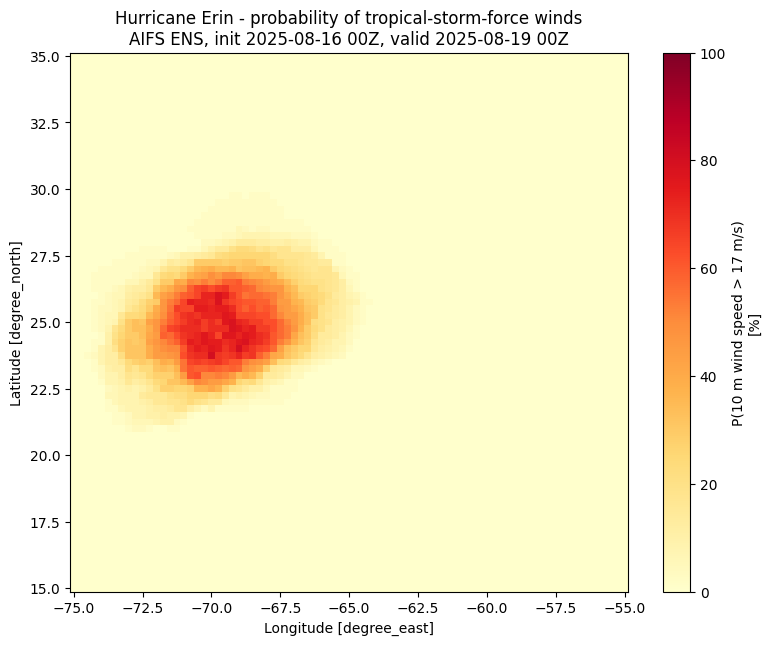

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# AIFS ENS run from 2025-08-16 00Z, 72 hours before Erin's peak intensity
plot_ds = ds.sel(
    init_time="2025-08-16T00",
    lead_time="72h",  # valid 2025-08-19 00 UTC
    latitude=slice(35, 15),
    longitude=slice(-75, -55),
)

wind_speed = np.sqrt(plot_ds["wind_u_10m"] ** 2 + plot_ds["wind_v_10m"] ** 2)
threshold_m_s = 17.0  # tropical-storm-force sustained winds (~33 kt)
prob = (wind_speed > threshold_m_s).mean(dim="ensemble_member") * 100
prob = prob.load()
prob.attrs["units"] = "%"
prob.attrs["long_name"] = f"P(10 m wind speed > {threshold_m_s:.0f} m/s)"

prob.plot(figsize=(9, 7), cmap="YlOrRd", vmin=0, vmax=100)
plt.title("Hurricane Erin - probability of tropical-storm-force winds\nAIFS ENS, init 2025-08-16 00Z, valid 2025-08-19 00Z")

### How fast does forecast uncertainty grow?

A fundamental property of ensembles is that spread (disagreement between members) grows with lead time. We'd expect it to be near zero at hour 0, and to broaden out over the 15-day forecast. Let's plot ensemble standard deviation at a point as a function of lead time, across many recent winter initializations.

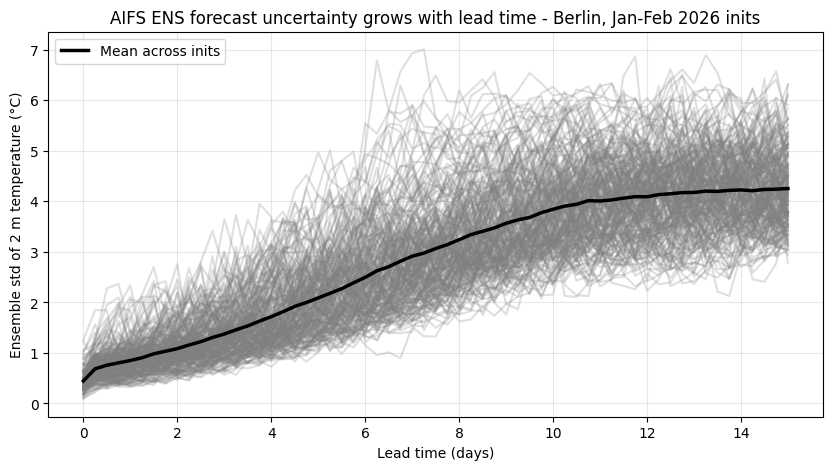

In [6]:
# Ensemble spread (standard deviation across ensemble members) of 2 m temperature at Berlin, for each Jan-Feb 2026 init
spread = (
    ds["temperature_2m"]
    .sel(latitude=52.52, longitude=13.40, method="nearest")
    .sel(init_time=slice("2026-01-01", "2026-02-28"))
    .std(dim="ensemble_member")
    .load()
)

lead_days = spread.lead_time / np.timedelta64(1, "D")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lead_days, spread.values.T, color="gray", alpha=0.25)
ax.plot(lead_days, spread.mean(dim="init_time").values, color="black", linewidth=2.5, label="Mean across inits")
ax.set_xlabel("Lead time (days)")
ax.set_ylabel("Ensemble std of 2 m temperature (°C)")
ax.set_title("AIFS ENS forecast uncertainty grows with lead time - Berlin, Jan-Feb 2026 inits")
ax.legend()
ax.grid(alpha=0.3)

### Animated ensemble mean — how sharp features blur with lead time

The ensemble mean averages over 51 plausible futures. For variables with sharp small-scale structure — like downward longwave radiation, which spikes under clouds and drops in clear skies — the early lead times look almost like one deterministic field, because the members still agree on where the clouds are. By a week out, the members have placed their clouds in different positions, and averaging over 51 of them smooths the field out.

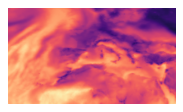

In [7]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

# Ensemble-mean downward longwave radiation over 10 days, sampled every 6 hours.
# Skip lead 0 since it's a deaccumulated rate with no first-window data.
data = (
    ds["downward_long_wave_radiation_flux_surface"]
    .sel(init_time="2025-10-01T00", lead_time=slice("6h", "240h"))
    .sel(latitude=slice(60, 20), longitude=slice(-30, 40))
    .mean(dim="ensemble_member")
    .load()
)

scale = 0.6
dpi = 80
fig, ax = plt.subplots(
    figsize=(data.longitude.size * scale / dpi, data.latitude.size * scale / dpi), dpi=dpi
)
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
ax.axis("off")

img = ax.imshow(data.isel(lead_time=0), cmap="magma", vmin=200, vmax=430)
anim = FuncAnimation(fig=fig, frames=data, func=lambda frame: img.set_data(frame), interval=180)

HTML(anim.to_jshtml())

### A few ideas to explore

AIFS ENS is a 51-member ensemble from an AI weather model — the same shape of dataset as ECMWF's physics-based IFS ENS and NOAA's GEFS, but powered by a fundamentally different model. That makes it especially rich for comparison work. A few ideas to spark exploration — each could be a notebook, a benchmark, or a small research project:

- **Tropical cyclone "spaghetti" tracks.** Track an Atlantic or Pacific cyclone across all 51 members by finding the minimum `pressure_reduced_to_mean_sea_level` in a moving box at each lead time. Plot the 51 paths and the ensemble-mean track. How does the track spread evolve from a 10-day-ahead forecast to a 1-day-ahead one?
- **AIFS ENS vs IFS ENS spread.** Both are 51-member ensembles out to 15 days. For a major storm (a hurricane, a polar vortex outbreak, a European windstorm), compare the spread of `temperature_2m`, `wind_u_10m`/`wind_v_10m`, and `pressure_reduced_to_mean_sea_level` at matched valid times. Does the AI ensemble underdisperse — i.e. claim more certainty than reality justifies — compared to the physics-based one?
- **AIFS ENS vs GEFS for cold snaps.** Cold extremes drive U.S. natural-gas demand and grid stress. Pick a recent cold air outbreak, compute the probability of `temperature_2m` below a threshold for both ensembles, and compare. Which catches the event earlier? Which has more honest spread?
- **Renewable "Dunkelflaute" risk.** Combine wind power proxies (`|V|³` at 100 m for offshore wind regions) and solar (`downward_short_wave_radiation_flux_surface`) to compute ensemble probability of multi-day periods of compound low generation across Europe or Texas. How far ahead can the ensemble flag these high-stress windows for grid operators?
- **Heat-dome probability via wet-bulb.** Compute wet-bulb temperature from `temperature_2m` and `dew_point_temperature_2m`. Map the probability of exceeding dangerous thresholds (e.g. 31 °C wet-bulb) during a summer heat dome. Compare AIFS ENS vs IFS ENS — do they agree on the spatial footprint and on how far out the signal emerges?
- **Hurricane intensity ensemble.** For an Atlantic storm, extract minimum `pressure_reduced_to_mean_sea_level` in a moving box at each lead time, per member. Plot the distribution of forecast intensity as a function of lead time. How does intensity spread compare to track spread for the same storm?
- **Ensemble calibration.** Are AIFS ENS members properly dispersed? Pick a 6 month period and a variable (e.g. 2 m temperature at a set of cities). Compute the rank histogram of the *observed* value (from a station dataset like ASOS, or from MRMS for precipitation) among the 51 ensemble forecasts at a fixed lead time. A flat histogram means good calibration; a U-shape means under-dispersion. How does that change between 1-day and 10-day lead times?